# Phase 2 — Data Understanding

Companion to PLAN.md Phase 2. Acquires Food-101, runs EDA, audits quality, and locks train/val/test splits. See `docs/superpowers/specs/2026-05-07-phase2-data-understanding-design.md`.

## 0. Setup

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm


In [2]:
# Constants — change deliberately, every downstream phase depends on these.
SEED = 42
VAL_FRACTION = 0.10
PIXEL_STATS_SAMPLE = 2000
TINY_SHORT_SIDE = 256
PHASH_HAMMING_THRESHOLD = 5
PHASH_SCOPE = 'within_class'

FORCE_REBUILD = False        # re-compute cached EDA / audit cells
REGENERATE_SPLITS = False    # re-shuffle splits (DANGEROUS — invalidates downstream comparisons)

random.seed(SEED)
np.random.seed(SEED)


In [3]:
# Paths — relative to repo root. Notebook is launched from repo root.
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
DATA_ROOT = REPO_ROOT / 'data'
ARTIFACTS_DIR = REPO_ROOT / 'artifacts' / 'phase2'
FIGURES_DIR = REPO_ROOT / 'figures' / 'phase2'
SPLITS_DIR = REPO_ROOT / 'splits'

for d in [DATA_ROOT, ARTIFACTS_DIR, FIGURES_DIR, FIGURES_DIR / 'samples', SPLITS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EDA_STATS_PATH = ARTIFACTS_DIR / 'eda_stats.json'
BAD_FILES_PATH = ARTIFACTS_DIR / 'bad_files.json'
PHASH_CACHE_PATH = ARTIFACTS_DIR / 'phash_cache.parquet'
AUDIT_CACHE_PATH = ARTIFACTS_DIR / 'audit_cache.parquet'

print(f'REPO_ROOT = {REPO_ROOT}')


REPO_ROOT = /Users/nguyenviethung/swin-transformer-classification


In [4]:
def update_stats(key, value):
    """Read eda_stats.json, set one key, write back. Idempotent."""
    stats = {}
    if EDA_STATS_PATH.exists():
        stats = json.loads(EDA_STATS_PATH.read_text())
    stats[key] = value
    EDA_STATS_PATH.write_text(json.dumps(stats, indent=2, sort_keys=True))
    return stats

# Seed eda_stats.json with the constants we already know.
update_stats('split_seed', SEED)
update_stats('imagenet_stats', {'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]})


{'class_counts': {'apple_pie': 750,
  'baby_back_ribs': 750,
  'baklava': 750,
  'beef_carpaccio': 750,
  'beef_tartare': 750,
  'beet_salad': 750,
  'beignets': 750,
  'bibimbap': 750,
  'bread_pudding': 750,
  'breakfast_burrito': 750,
  'bruschetta': 750,
  'caesar_salad': 750,
  'cannoli': 750,
  'caprese_salad': 750,
  'carrot_cake': 750,
  'ceviche': 750,
  'cheese_plate': 750,
  'cheesecake': 750,
  'chicken_curry': 750,
  'chicken_quesadilla': 750,
  'chicken_wings': 750,
  'chocolate_cake': 750,
  'chocolate_mousse': 750,
  'churros': 750,
  'clam_chowder': 750,
  'club_sandwich': 750,
  'crab_cakes': 750,
  'creme_brulee': 750,
  'croque_madame': 750,
  'cup_cakes': 750,
  'deviled_eggs': 750,
  'donuts': 750,
  'dumplings': 750,
  'edamame': 750,
  'eggs_benedict': 750,
  'escargots': 750,
  'falafel': 750,
  'filet_mignon': 750,
  'fish_and_chips': 750,
  'foie_gras': 750,
  'french_fries': 750,
  'french_onion_soup': 750,
  'french_toast': 750,
  'fried_calamari': 750,
  '

In [5]:
# ASSERT: setup primitives are defined and paths exist
for name in ['SEED', 'VAL_FRACTION', 'PIXEL_STATS_SAMPLE', 'TINY_SHORT_SIDE',
             'PHASH_HAMMING_THRESHOLD', 'PHASH_SCOPE', 'FORCE_REBUILD',
             'REGENERATE_SPLITS', 'DATA_ROOT', 'ARTIFACTS_DIR', 'FIGURES_DIR',
             'SPLITS_DIR', 'EDA_STATS_PATH', 'BAD_FILES_PATH', 'update_stats']:
    assert name in dir(), f'missing setup symbol: {name}'
for d in [DATA_ROOT, ARTIFACTS_DIR, FIGURES_DIR, SPLITS_DIR]:
    assert d.exists(), f'missing dir: {d}'
print('setup OK')

setup OK


## 1. Acquisition
Downloads Food-101 from the official ETH Zurich URL via torchvision. torchvision verifies the MD5 internally; if the checksum fails it raises.

In [6]:
from torchvision.datasets import Food101

# torchvision caches under DATA_ROOT/food-101/. download=True is a no-op if already present.
train_ds = Food101(root=str(DATA_ROOT), split='train', download=True)
test_ds  = Food101(root=str(DATA_ROOT), split='test',  download=True)

class_names = sorted(train_ds.classes)
label_to_idx = {c: i for i, c in enumerate(class_names)}


In [7]:
# Build flat path lists. Use repo-relative paths so split CSVs survive moving the data dir.
IMAGES_DIR = DATA_ROOT / 'food-101' / 'images'

def _read_meta(split):
    meta_file = DATA_ROOT / 'food-101' / 'meta' / f'{split}.txt'
    return [line.strip() for line in meta_file.read_text().splitlines() if line.strip()]

def _to_records(meta_lines):
    out = []
    for line in meta_lines:
        cls, fname = line.split('/')
        rel = f'data/food-101/images/{cls}/{fname}.jpg'
        out.append({'filepath': rel, 'label_name': cls, 'label_idx': label_to_idx[cls]})
    return out

train_files = _to_records(_read_meta('train'))
test_files  = _to_records(_read_meta('test'))

print(f'train={len(train_files):,}  test={len(test_files):,}  classes={len(class_names)}')
print('first 3 train paths:')
for r in train_files[:3]:
    print(' ', r['filepath'])


train=75,750  test=25,250  classes=101
first 3 train paths:
  data/food-101/images/apple_pie/1005649.jpg
  data/food-101/images/apple_pie/1014775.jpg
  data/food-101/images/apple_pie/1026328.jpg


In [8]:
# ASSERT: dataset acquired and inventoried
assert (DATA_ROOT / 'food-101' / 'images').exists(), 'food-101 images dir missing'
assert len(train_files) == 75750, f'expected 75750 train files, got {len(train_files)}'
assert len(test_files) == 25250, f'expected 25250 test files, got {len(test_files)}'
assert len(class_names) == 101, f'expected 101 classes, got {len(class_names)}'
print('acquisition OK')

acquisition OK


## 2. Class Distribution
Food-101 ships balanced (750 train / 250 test per class). We confirm rather than assume.

In [9]:
from collections import Counter

train_counts = Counter(r['label_name'] for r in train_files)
test_counts  = Counter(r['label_name'] for r in test_files)

balance_ok = (set(train_counts.values()) == {750}) and (set(test_counts.values()) == {250})
print(f'balanced exactly 750/250 per class: {balance_ok}')


balanced exactly 750/250 per class: True


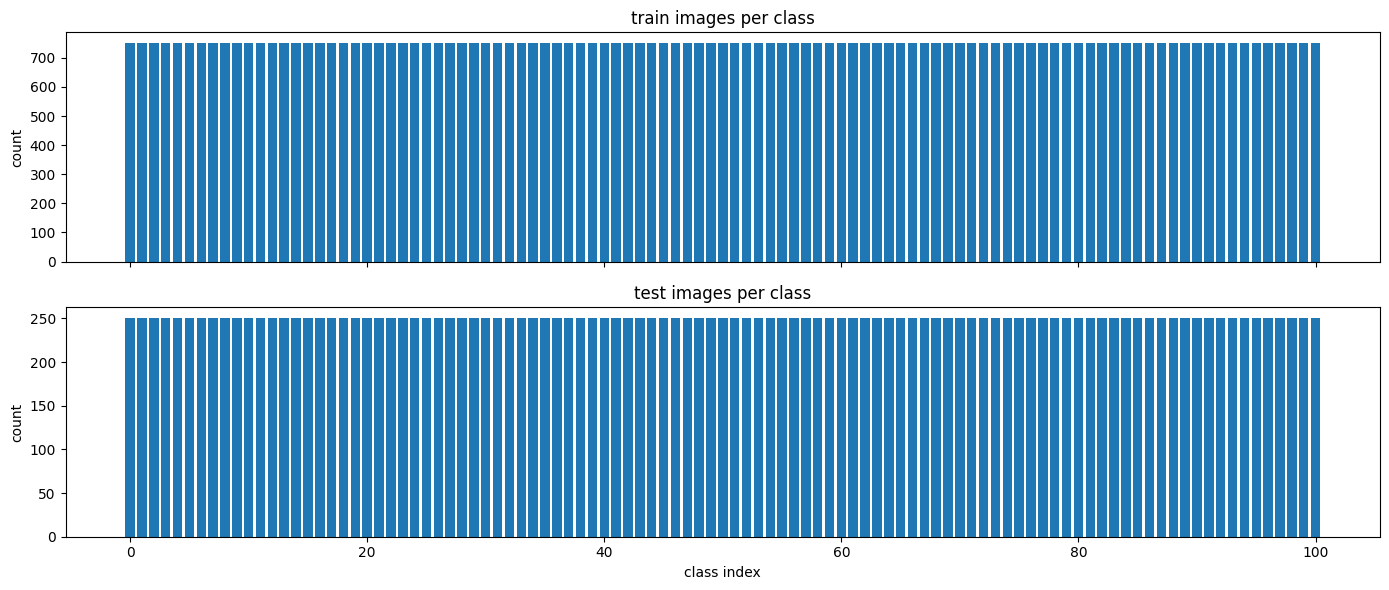

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ordered = sorted(class_names)
axes[0].bar(range(len(ordered)), [train_counts[c] for c in ordered])
axes[0].set_title('train images per class')
axes[0].set_ylabel('count')
axes[1].bar(range(len(ordered)), [test_counts[c] for c in ordered])
axes[1].set_title('test images per class')
axes[1].set_ylabel('count')
axes[1].set_xlabel('class index')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'class_dist.png', dpi=150)
plt.show()


In [11]:
update_stats('n_train', len(train_files))
update_stats('n_test', len(test_files))
update_stats('n_classes', len(class_names))
update_stats('class_counts', dict(train_counts))


{'class_counts': {'apple_pie': 750,
  'baby_back_ribs': 750,
  'baklava': 750,
  'beef_carpaccio': 750,
  'beef_tartare': 750,
  'beet_salad': 750,
  'beignets': 750,
  'bibimbap': 750,
  'bread_pudding': 750,
  'breakfast_burrito': 750,
  'bruschetta': 750,
  'caesar_salad': 750,
  'cannoli': 750,
  'caprese_salad': 750,
  'carrot_cake': 750,
  'ceviche': 750,
  'cheesecake': 750,
  'cheese_plate': 750,
  'chicken_curry': 750,
  'chicken_quesadilla': 750,
  'chicken_wings': 750,
  'chocolate_cake': 750,
  'chocolate_mousse': 750,
  'churros': 750,
  'clam_chowder': 750,
  'club_sandwich': 750,
  'crab_cakes': 750,
  'creme_brulee': 750,
  'croque_madame': 750,
  'cup_cakes': 750,
  'deviled_eggs': 750,
  'donuts': 750,
  'dumplings': 750,
  'edamame': 750,
  'eggs_benedict': 750,
  'escargots': 750,
  'falafel': 750,
  'filet_mignon': 750,
  'fish_and_chips': 750,
  'foie_gras': 750,
  'french_fries': 750,
  'french_onion_soup': 750,
  'french_toast': 750,
  'fried_calamari': 750,
  '

In [12]:
# ASSERT: class distribution computed and persisted
import json as _json
stats = _json.loads(EDA_STATS_PATH.read_text())
assert 'class_counts' in stats and 'n_train' in stats and 'n_test' in stats and 'n_classes' in stats
assert stats['n_train'] == 75750
assert stats['n_test']  == 25250
assert stats['n_classes'] == 101
assert len(stats['class_counts']) == 101
assert (FIGURES_DIR / 'class_dist.png').exists()
print('class distribution OK')

class distribution OK


## 3. Image Dimensions
Reads width/height (without decoding pixels) for every train+test image. Informs the resize strategy in Phase 3.

In [13]:
DIMS_CACHE = ARTIFACTS_DIR / 'dims_cache.parquet'

if DIMS_CACHE.exists() and not FORCE_REBUILD:
    dims_df = pd.read_parquet(DIMS_CACHE)
    print(f'loaded cached dimensions for {len(dims_df):,} images — set FORCE_REBUILD=True to recompute')
else:
    rows = []
    for r in tqdm(train_files + test_files, desc='reading dims'):
        path = REPO_ROOT / r['filepath']
        try:
            with Image.open(path) as im:
                w, h = im.size
        except Exception:
            w, h = -1, -1   # corrupt — picked up properly in section 6a
        rows.append({'filepath': r['filepath'], 'width': w, 'height': h})
    dims_df = pd.DataFrame(rows)
    dims_df['aspect'] = dims_df['width'] / dims_df['height']
    dims_df.to_parquet(DIMS_CACHE)
    print(f'computed and cached dimensions for {len(dims_df):,} images')


loaded cached dimensions for 101,000 images — set FORCE_REBUILD=True to recompute


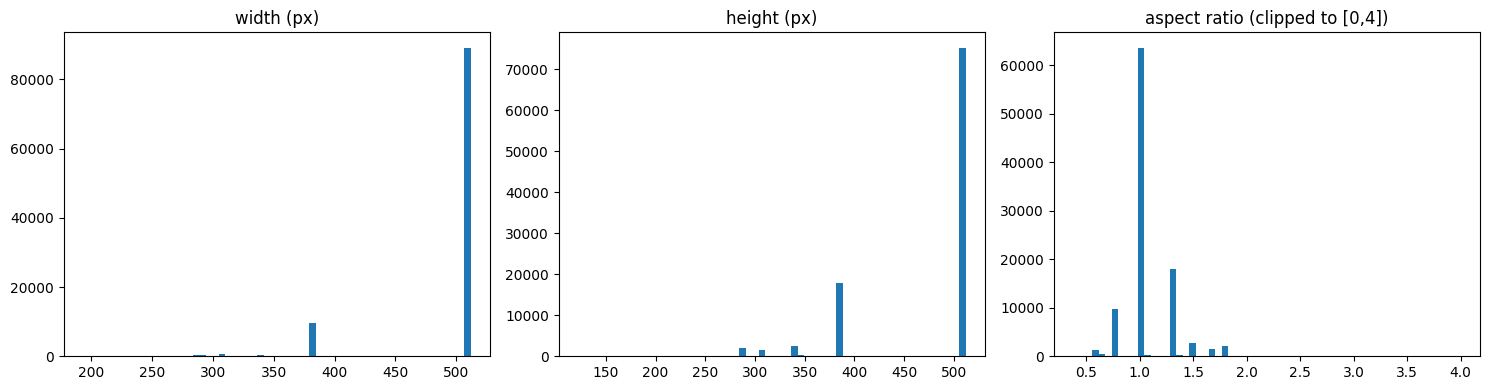

In [14]:
valid = dims_df[(dims_df['width'] > 0) & (dims_df['height'] > 0)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(valid['width'], bins=60); axes[0].set_title('width (px)')
axes[1].hist(valid['height'], bins=60); axes[1].set_title('height (px)')
axes[2].hist(valid['aspect'].clip(0, 4), bins=60); axes[2].set_title('aspect ratio (clipped to [0,4])')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'dims_hist.png', dpi=150)
plt.show()


In [15]:
def _summary(s):
    return {
        'min':  float(s.min()), 'max':  float(s.max()),
        'mean': float(s.mean()),
        'p50':  float(s.quantile(0.50)), 'p95': float(s.quantile(0.95)),
    }

update_stats('dims', {
    'width':  _summary(valid['width']),
    'height': _summary(valid['height']),
    'aspect': _summary(valid['aspect']),
})


{'class_counts': {'apple_pie': 750,
  'baby_back_ribs': 750,
  'baklava': 750,
  'beef_carpaccio': 750,
  'beef_tartare': 750,
  'beet_salad': 750,
  'beignets': 750,
  'bibimbap': 750,
  'bread_pudding': 750,
  'breakfast_burrito': 750,
  'bruschetta': 750,
  'caesar_salad': 750,
  'cannoli': 750,
  'caprese_salad': 750,
  'carrot_cake': 750,
  'ceviche': 750,
  'cheese_plate': 750,
  'cheesecake': 750,
  'chicken_curry': 750,
  'chicken_quesadilla': 750,
  'chicken_wings': 750,
  'chocolate_cake': 750,
  'chocolate_mousse': 750,
  'churros': 750,
  'clam_chowder': 750,
  'club_sandwich': 750,
  'crab_cakes': 750,
  'creme_brulee': 750,
  'croque_madame': 750,
  'cup_cakes': 750,
  'deviled_eggs': 750,
  'donuts': 750,
  'dumplings': 750,
  'edamame': 750,
  'eggs_benedict': 750,
  'escargots': 750,
  'falafel': 750,
  'filet_mignon': 750,
  'fish_and_chips': 750,
  'foie_gras': 750,
  'french_fries': 750,
  'french_onion_soup': 750,
  'french_toast': 750,
  'fried_calamari': 750,
  '

In [16]:
# ASSERT: dimension stats computed and persisted
import json as _json
stats = _json.loads(EDA_STATS_PATH.read_text())
assert 'dims' in stats
for k in ('width', 'height', 'aspect'):
    assert k in stats['dims']
    for stat in ('min', 'max', 'mean', 'p50', 'p95'):
        assert stat in stats['dims'][k], f'missing dims.{k}.{stat}'
assert (FIGURES_DIR / 'dims_hist.png').exists()
assert (ARTIFACTS_DIR / 'dims_cache.parquet').exists()
print('dimensions OK')

dimensions OK


## 4. Per-Channel Pixel Statistics
Sample 2000 train images, compute RGB mean/std at native resolution. Compare to ImageNet stats — if close, we use ImageNet normalization in Phase 3.

In [17]:
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(train_files), size=PIXEL_STATS_SAMPLE, replace=False)
sums = np.zeros(3, dtype=np.float64)
sumsq = np.zeros(3, dtype=np.float64)
n_pix = 0
for i in tqdm(sample_idx, desc='pixel stats'):
    p = REPO_ROOT / train_files[int(i)]['filepath']
    try:
        with Image.open(p) as im:
            arr = np.asarray(im.convert('RGB'), dtype=np.float64) / 255.0
    except Exception:
        continue
    sums  += arr.reshape(-1, 3).sum(axis=0)
    sumsq += (arr.reshape(-1, 3) ** 2).sum(axis=0)
    n_pix += arr.shape[0] * arr.shape[1]

mean = sums / n_pix
std  = np.sqrt(sumsq / n_pix - mean ** 2)
print(f'computed mean = {mean}')
print(f'computed std  = {std}')


pixel stats:   0%|          | 0/2000 [00:00<?, ?it/s]

computed mean = [0.5494268  0.44438435 0.34286873]
computed std  = [0.27232768 0.27565284 0.27807522]


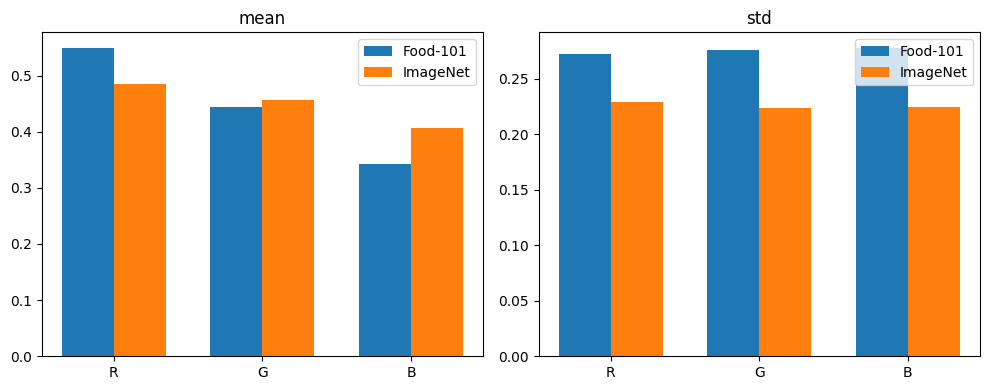

In [18]:
imnet_mean = np.array([0.485, 0.456, 0.406])
imnet_std  = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(3); w = 0.35; channels = ['R', 'G', 'B']
axes[0].bar(x - w/2, mean, w, label='Food-101')
axes[0].bar(x + w/2, imnet_mean, w, label='ImageNet')
axes[0].set_xticks(x); axes[0].set_xticklabels(channels); axes[0].set_title('mean')
axes[0].legend()
axes[1].bar(x - w/2, std, w, label='Food-101')
axes[1].bar(x + w/2, imnet_std, w, label='ImageNet')
axes[1].set_xticks(x); axes[1].set_xticklabels(channels); axes[1].set_title('std')
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'pixel_stats.png', dpi=150)
plt.show()


In [19]:
update_stats('pixel_stats_native', {
    'mean': mean.tolist(),
    'std':  std.tolist(),
    'n_sampled': PIXEL_STATS_SAMPLE,
})


{'class_counts': {'apple_pie': 750,
  'baby_back_ribs': 750,
  'baklava': 750,
  'beef_carpaccio': 750,
  'beef_tartare': 750,
  'beet_salad': 750,
  'beignets': 750,
  'bibimbap': 750,
  'bread_pudding': 750,
  'breakfast_burrito': 750,
  'bruschetta': 750,
  'caesar_salad': 750,
  'cannoli': 750,
  'caprese_salad': 750,
  'carrot_cake': 750,
  'ceviche': 750,
  'cheese_plate': 750,
  'cheesecake': 750,
  'chicken_curry': 750,
  'chicken_quesadilla': 750,
  'chicken_wings': 750,
  'chocolate_cake': 750,
  'chocolate_mousse': 750,
  'churros': 750,
  'clam_chowder': 750,
  'club_sandwich': 750,
  'crab_cakes': 750,
  'creme_brulee': 750,
  'croque_madame': 750,
  'cup_cakes': 750,
  'deviled_eggs': 750,
  'donuts': 750,
  'dumplings': 750,
  'edamame': 750,
  'eggs_benedict': 750,
  'escargots': 750,
  'falafel': 750,
  'filet_mignon': 750,
  'fish_and_chips': 750,
  'foie_gras': 750,
  'french_fries': 750,
  'french_onion_soup': 750,
  'french_toast': 750,
  'fried_calamari': 750,
  '

In [20]:
# ASSERT: pixel stats computed and persisted
import json as _json
stats = _json.loads(EDA_STATS_PATH.read_text())
ps = stats.get('pixel_stats_native')
assert ps is not None and 'mean' in ps and 'std' in ps and 'n_sampled' in ps
assert len(ps['mean']) == 3 and len(ps['std']) == 3
assert ps['n_sampled'] == PIXEL_STATS_SAMPLE
assert all(0.0 < m < 1.0 for m in ps['mean']), f'pixel means look wrong: {ps["mean"]}'
assert (FIGURES_DIR / 'pixel_stats.png').exists()
print('pixel stats OK')

pixel stats OK
